<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/Train_Overall_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [ ]:
MODEL_PARAMS = {
    'n_estimators': 500,
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'objective': 'reg:squarederror'
}

In [ ]:
def load_data(file_path):
    df = pd.read_csv(file_path)

    data_df = df.copy()

    data_df['Date'] = pd.to_datetime(
        data_df['Date'],
        dayfirst=True
    )

    data_df = data_df.sort_values(
        ['BranchID', 'Date']
    )

    return data_df

In [ ]:
TARGET_COLUMNS = [
    'CountofGroup',
    'CountofClientName',
    'CountofAccountID',
    'CountofCreditOfficerID',
    'SumofPrincipalOutstanding',
    'SumofInterestOutstanding',
    'SumofTotalPrincipalOverdue',
    'SumofTotalInterestOverdue',
    'SumofTotalPAR'
]

FEATURES = [
    'lag_1',
    'lag_2',
    'ema_7',
    'lag_3',
    'diff_1'
]


def create_time_series_features(
    data_df,
    target_columns,
    group_col='BranchID'
):
    data_df['day'] = data_df['Date'].dt.day

    data_df['month'] = data_df['Date'].dt.month

    data_df['year'] = data_df['Date'].dt.year

    data_df['dayofweek'] = (
        data_df['Date'].dt.dayofweek
    )

    for col in target_columns:
        for lag in [1, 2, 3]:
            data_df[f'{col}_lag_{lag}'] = (
                data_df
                .groupby(group_col)[col]
                .shift(lag)
            )

        data_df[f'{col}_ema_7'] = (
            data_df
            .groupby(group_col)[col]
            .transform(
                lambda x: x.shift(1).ewm(span=7).mean()
            )
        )

        data_df[f'{col}_diff_1'] = (
            data_df
            .groupby(group_col)[col]
            .diff(1)
        )

    return data_df

In [ ]:
def split_data(data_df, split_date):
    overall_train_df = data_df[
        data_df['Date'] < split_date
    ]

    overall_test_df = data_df[
        data_df['Date'] >= split_date
    ]

    return (
        overall_train_df,
        overall_test_df
    )

In [ ]:
def get_feature_list(TARGET_COLUMN):
  return [
      'day',
      'month',
      'year',
      'dayofweek',
      'BranchID',
      f'{TARGET_COLUMN}_lag_1',
      f'{TARGET_COLUMN}_lag_2',
      f'{TARGET_COLUMN}_lag_3',
      f'{TARGET_COLUMN}_ema_7',
      f'{TARGET_COLUMN}_diff_1'
  ]

In [ ]:
def getTrain_and_Test_data(COLUMN_TO_TAKE):
  X_train = overall_train_df[get_feature_list(COLUMN_TO_TAKE)]
  y_train = overall_train_df[COLUMN_TO_TAKE]

  X_test = overall_test_df[get_feature_list(COLUMN_TO_TAKE)]
  y_test = overall_test_df[COLUMN_TO_TAKE]

  return X_train, y_train, X_test, y_test

In [ ]:
def train_model(
    X_train,
    y_train,
    X_test,
    y_test,
    params
):
    model = XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        verbose=100
    )

    return model

In [ ]:
def compare_test_and_pred(train_data,actual, predicted):
  comparision_df = train_data[
    ['BranchID']
  ].copy()
  comparision_df['Date'] = pd.to_datetime(
        train_data[['year', 'month', 'day']]
    ).dt.strftime('%d-%m-%Y')
  comparision_df['Actual'] = actual.values
  comparision_df['Predicted'] = predicted
  return comparision_df

In [ ]:
def evaluate_metrics(actual, predicted):
  mae = mean_absolute_error(
      actual,
      predicted
  )

  mse = mean_squared_error(
      actual,
      predicted
  )

  rmse = np.sqrt(mse)


  mape = np.mean(
      np.abs(
          (actual - predicted)
          / np.where(actual == 0, 1, actual)
      )
  ) * 100


  smape = np.mean(
      2 * np.abs(predicted - actual)
      / (
          np.abs(actual)
          + np.abs(predicted)
          + 1e-10
      )
  ) * 100

  print("========== METRICS ==========")
  print(f"MAE  : {mae:,.2f}")
  print(f"MSE  : {mse:,.2f}")
  print(f"RMSE : {rmse:,.2f}")
  print(f"MAPE : {mape:.2f}%")
  print(f"SMAPE: {smape:.2f}%")

In [ ]:
def plot_graph(result_data, branchId):
  data = result_data[
    result_data['BranchID'] == branchId
  ].copy()
  data['Date'] = pd.to_datetime(data['Date'], format='%d-%m-%Y')
  data = data.sort_values('Date')
  plt.figure(figsize=(18,6))
  plt.plot(
      data['Date'],
      data['Actual'],
      label='Actual',
      linewidth=2,
      marker='o'
  )
  plt.plot(
      data['Date'],
      data['Predicted'],
      label='Predicted',
      linewidth=2,
      marker='x'
  )
  plt.title(
      f'Branch {branchId}'
  )
  plt.legend()
  plt.grid()
  plt.xticks(rotation=45)
  plt.show()

In [ ]:
def forecast_next_30_days(
    model,
    data_df,
    branch_id,
    target_col,
    features
):
    forecast = []

    branch_df = data_df[
        data_df['BranchID'] == branch_id
    ].sort_values('Date').copy()

    last_date = branch_df['Date'].max()

    history = branch_df[target_col].tolist()

    for i in range(1, 31):

        future_date = last_date + pd.Timedelta(days=i)

        # --------------------------
        # Build feature row
        # --------------------------
        new_row = {}

        new_row['BranchID'] = branch_id

        new_row['day'] = future_date.day
        new_row['month'] = future_date.month
        new_row['year'] = future_date.year
        new_row['dayofweek'] = future_date.dayofweek

        # --------------------------
        # LAG FEATURES
        # --------------------------
        new_row[f'{target_col}_lag_1'] = history[-1]
        new_row[f'{target_col}_lag_2'] = history[-2]
        new_row[f'{target_col}_lag_3'] = history[-3]

        # EMA (simple approx)
        series = pd.Series(history)
        new_row[f'{target_col}_ema_7'] = series.ewm(span=7).mean().iloc[-1]

        # DIFF
        new_row[f'{target_col}_diff_1'] = history[-1] - history[-2]

        # --------------------------
        # Predict
        # --------------------------
        X_input = pd.DataFrame([new_row])[features]

        pred = model.predict(X_input)[0]

        # store result
        forecast.append({
            'Date': future_date,
            'BranchID': branch_id,
            'Predicted': pred
        })

        # IMPORTANT: append prediction to history
        history.append(pred)

    return pd.DataFrame(forecast)

[0]	validation_0-rmse:5322391.83030
[100]	validation_0-rmse:1938180.65452
[200]	validation_0-rmse:713314.95592
[300]	validation_0-rmse:316019.77580
[400]	validation_0-rmse:242120.41755
[499]	validation_0-rmse:243437.69541
========== ACTUAL VS PREDICTED ==========
        BranchID        Date  Actual     Predicted
166894       152  01-04-2026       0  23639.484375
167046       152  02-04-2026       0  23639.484375
167198       152  03-04-2026       0  23639.484375
167350       152  04-04-2026       0  23639.484375
167502       152  05-04-2026       0  23639.484375
167654       152  06-04-2026       0  23639.484375
167806       152  07-04-2026       0  23639.484375
167958       152  08-04-2026       0  23639.484375
168110       152  09-04-2026       0  23639.484375
168262       152  10-04-2026       0  23639.484375
168414       152  11-04-2026       0  23639.484375
168566       152  12-04-2026       0  23639.484375
168718       152  13-04-2026       0  23639.484375
168870       152  14-0

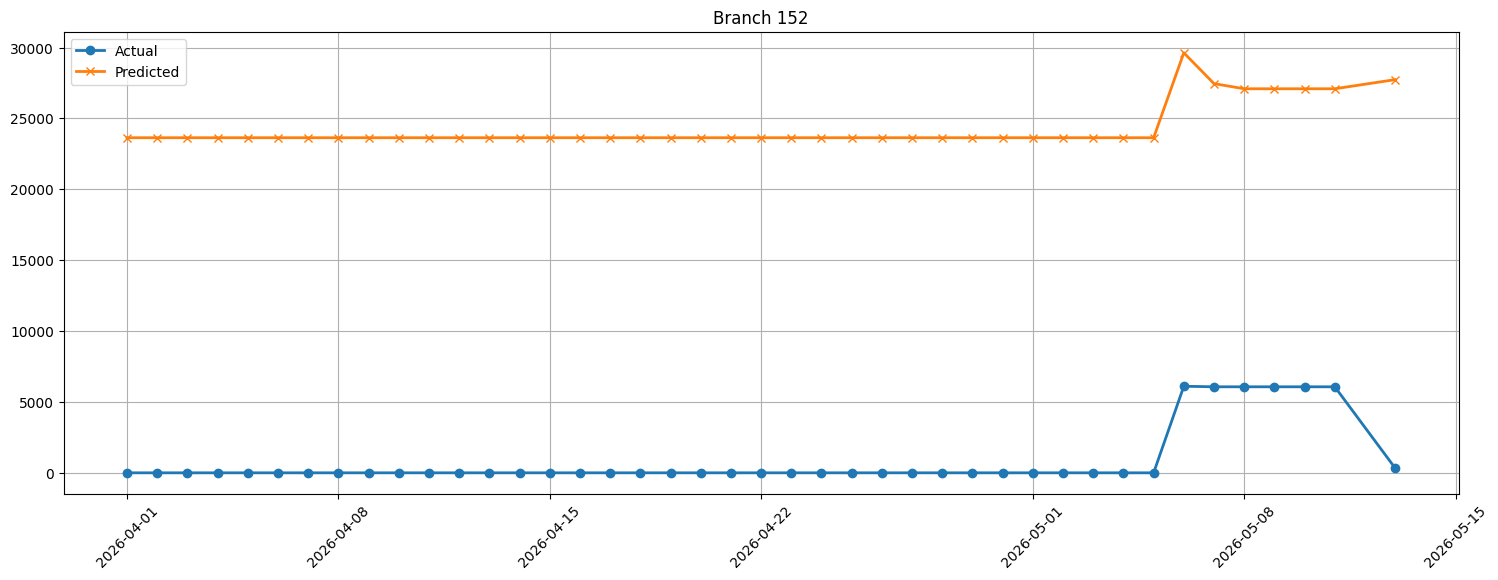

,Date,BranchID,Predicted
0,2026-05-14,152,25133.326172
1,2026-05-15,152,59608.140625
2,2026-05-16,152,98113.406250
3,2026-05-17,152,118857.125000
4,2026-05-18,152,137872.812500


In [ ]:
TRAIN_END_DATE = '2026-04-01'
TO_PREDICT_COLUMN = 'SumofTotalPrincipalOverdue'
TO_PREDICT_BRANCHID = 152

df = load_data('/content/dat.csv')
data_df = create_time_series_features(
    df,
    TARGET_COLUMNS
)

# --Train/Test Split--
(
  overall_train_df,
  overall_test_df
) = split_data(
  data_df,
  TRAIN_END_DATE
)

# --GET X and Y
X_train, y_train, X_test, y_test = getTrain_and_Test_data(TO_PREDICT_COLUMN)

# -- Train Models
model = train_model(
        X_train,
        y_train,
        X_test,
        y_test,
        MODEL_PARAMS
    )

# --Predict
preds = model.predict(X_test)

# --Comapre Test Actual vs Predicted
compared_result = compare_test_and_pred(X_test,y_test, preds)
print("========== ACTUAL VS PREDICTED ==========")
print(compared_result[compared_result['BranchID']==TO_PREDICT_BRANCHID])

# --Evaluate Metrics
evaluate_metrics(y_test, preds)

# --Plot Graph
plot_graph(compared_result, TO_PREDICT_BRANCHID)

# --Forecast for Future days
future_pred = forecast_next_30_days(model,data_df,TO_PREDICT_BRANCHID,TO_PREDICT_COLUMN,get_feature_list(TO_PREDICT_COLUMN) )
future_pred.head()

[0]	validation_0-rmse:3.24132
[100]	validation_0-rmse:0.52844
[200]	validation_0-rmse:0.48224
[300]	validation_0-rmse:0.46812
[400]	validation_0-rmse:0.46807
[500]	validation_0-rmse:0.46613
[600]	validation_0-rmse:0.46760
[700]	validation_0-rmse:0.46899
[800]	validation_0-rmse:0.47002
[900]	validation_0-rmse:0.47014
[999]	validation_0-rmse:0.47106

========== METRICS ==========

MAE  : 223,871.37
RMSE : 1,266,037.69

========== ACTUAL VS PREDICTED ==========

      BranchID       Date     Actual     Predicted
1067         1 2026-04-01  7247838.0  7.230042e+06
1068         1 2026-04-02  7257621.0  7.230442e+06
1069         1 2026-04-03  7258864.0  7.224762e+06
1070         1 2026-04-04  7274759.0  7.242560e+06
1071         1 2026-04-05  7274759.0  7.279441e+06
1072         1 2026-04-06  7277729.0  7.313244e+06
1073         1 2026-04-07  7292484.0  7.324028e+06
1074         1 2026-04-08  5229689.0  7.142416e+06
1075         1 2026-04-09  5232726.0  5.563724e+06
1076         1 2026-04-10 

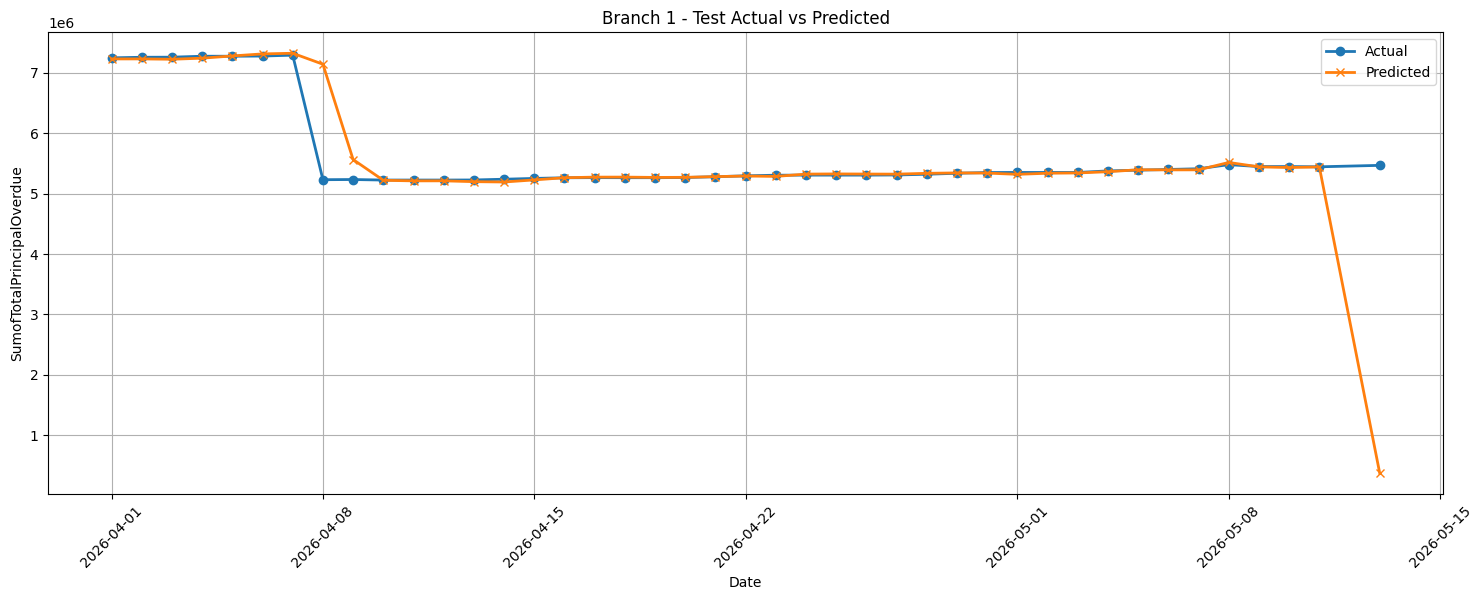


========== FUTURE FORECAST ==========

         Date  BranchID   Forecast
0  2026-05-14         1  5502450.5
1  2026-05-15         1  5520474.0
2  2026-05-16         1  5551443.0
3  2026-05-17         1  5565395.0
4  2026-05-18         1  5550517.0
5  2026-05-19         1  5542683.0
6  2026-05-20         1  5533393.0
7  2026-05-21         1  5532480.0
8  2026-05-22         1  5537816.5
9  2026-05-23         1  5545157.0
10 2026-05-24         1  5543761.0
11 2026-05-25         1  5535282.0
12 2026-05-26         1  5531161.0
13 2026-05-27         1  5535245.0
14 2026-05-28         1  5543803.5
15 2026-05-29         1  5546664.5
16 2026-05-30         1  5543116.0
17 2026-05-31         1  5534738.5
18 2026-06-01         1  5530639.0
19 2026-06-02         1  5535076.5
20 2026-06-03         1  5541578.0
21 2026-06-04         1  5543713.5
22 2026-06-05         1  5540257.0
23 2026-06-06         1  5536729.0
24 2026-06-07         1  5536253.5
25 2026-06-08         1  5537605.5
26 2026-06-09  

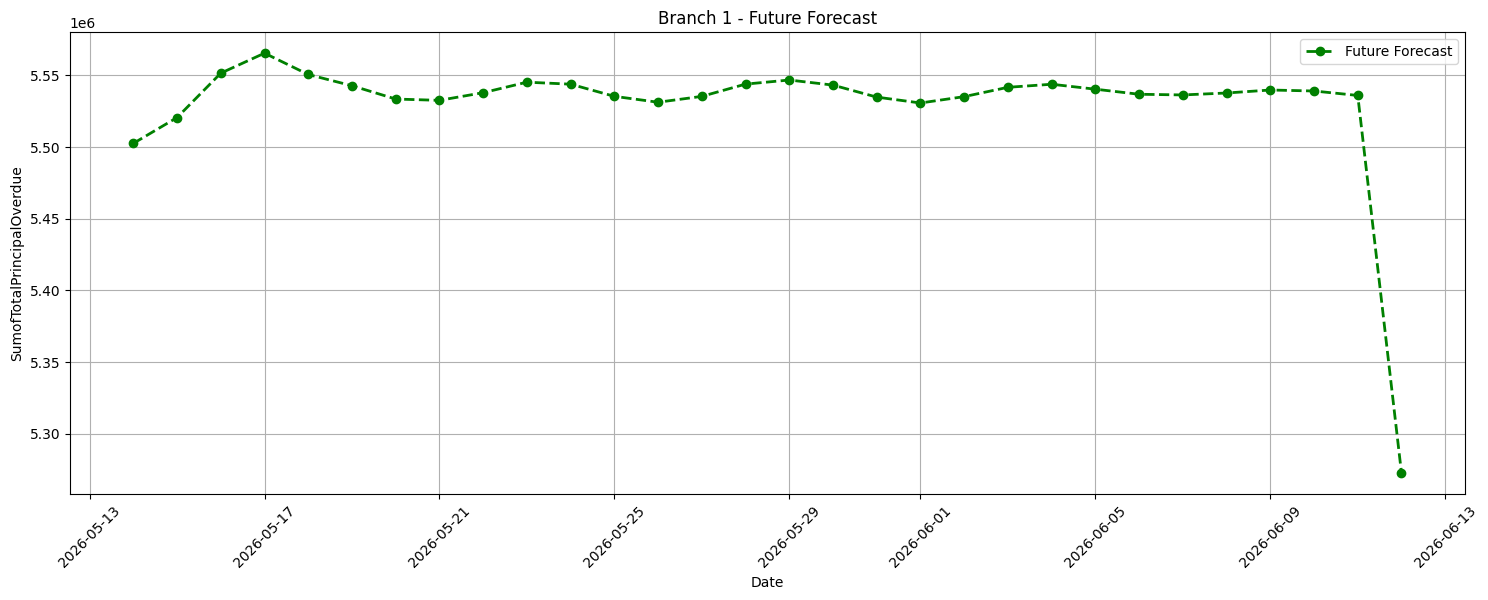


========== FEATURE IMPORTANCE ==========

             Feature  Importance
24           is_zero    0.425458
22             ema_7    0.388647
7              lag_1    0.141585
20    rolling_max_14    0.023797
19     rolling_max_7    0.015333
21    rolling_max_30    0.001639
8              lag_2    0.001245
9              lag_3    0.001192
15   rolling_mean_30    0.000432
13    rolling_mean_7    0.000153
23            diff_1    0.000130
6       is_month_end    0.000109
25       zero_streak    0.000082
10             lag_7    0.000066
2              month    0.000042
14   rolling_mean_14    0.000023
0   BranchID_encoded    0.000023
12            lag_30    0.000014
11            lag_14    0.000010
1                day    0.000006


In [ ]:
# ============================================================
# FULL TIME SERIES FORECASTING PIPELINE
# XGBOOST + FUTURE FORECASTING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.preprocessing import LabelEncoder

# ============================================================
# CONFIG
# ============================================================

FILE_PATH = "/content/dat.csv"

TARGET_COLUMN = "SumofTotalPrincipalOverdue"

TRAIN_END_DATE = "2026-04-01"

BRANCH_TO_PLOT = 1

FORECAST_DAYS = 30

MODEL_PARAMS = {
    "n_estimators": 1000,
    "learning_rate": 0.03,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "reg:squarederror",
    "random_state": 42
}

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(FILE_PATH)

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df = df.sort_values(
    ["BranchID", "Date"]
)

# ============================================================
# FILL MISSING DATES
# ============================================================

all_branch_frames = []

for branch_id, grp in df.groupby("BranchID"):

    grp = grp.sort_values("Date")

    full_dates = pd.date_range(
        grp["Date"].min(),
        grp["Date"].max(),
        freq="D"
    )

    grp = (
        grp
        .set_index("Date")
        .reindex(full_dates)
    )

    grp["BranchID"] = branch_id

    grp.index.name = "Date"

    grp = grp.reset_index()

    grp[TARGET_COLUMN] = (
        grp[TARGET_COLUMN]
        .fillna(0)
    )

    all_branch_frames.append(grp)

df = pd.concat(all_branch_frames)

df = df.rename(columns={"index": "Date"})

# ============================================================
# ENCODE BRANCH ID
# ============================================================

le = LabelEncoder()

df["BranchID_encoded"] = le.fit_transform(
    df["BranchID"]
)

# ============================================================
# FEATURE ENGINEERING
# ============================================================

def create_features(data):

    data = data.sort_values(
        ["BranchID", "Date"]
    )

    # ------------------------------------------------
    # DATE FEATURES
    # ------------------------------------------------

    data["day"] = data["Date"].dt.day

    data["month"] = data["Date"].dt.month

    data["year"] = data["Date"].dt.year

    data["dayofweek"] = (
        data["Date"].dt.dayofweek
    )

    data["is_month_start"] = (
        data["Date"].dt.is_month_start.astype(int)
    )

    data["is_month_end"] = (
        data["Date"].dt.is_month_end.astype(int)
    )

    # ------------------------------------------------
    # LAG FEATURES
    # ------------------------------------------------

    for lag in [1, 2, 3, 7, 14, 30]:

        data[f"lag_{lag}"] = (
            data
            .groupby("BranchID")[TARGET_COLUMN]
            .shift(lag)
        )

    # ------------------------------------------------
    # ROLLING FEATURES
    # ------------------------------------------------

    for win in [7, 14, 30]:

        data[f"rolling_mean_{win}"] = (
            data
            .groupby("BranchID")[TARGET_COLUMN]
            .transform(
                lambda x:
                x.shift(1).rolling(win).mean()
            )
        )

        data[f"rolling_std_{win}"] = (
            data
            .groupby("BranchID")[TARGET_COLUMN]
            .transform(
                lambda x:
                x.shift(1).rolling(win).std()
            )
        )

        data[f"rolling_max_{win}"] = (
            data
            .groupby("BranchID")[TARGET_COLUMN]
            .transform(
                lambda x:
                x.shift(1).rolling(win).max()
            )
        )

    # ------------------------------------------------
    # EMA
    # ------------------------------------------------

    data["ema_7"] = (
        data
        .groupby("BranchID")[TARGET_COLUMN]
        .transform(
            lambda x:
            x.shift(1).ewm(span=7).mean()
        )
    )

    # ------------------------------------------------
    # DIFF
    # ------------------------------------------------

    data["diff_1"] = (
        data
        .groupby("BranchID")[TARGET_COLUMN]
        .diff(1)
    )

    # ------------------------------------------------
    # ZERO FEATURES
    # ------------------------------------------------

    data["is_zero"] = (
        data[TARGET_COLUMN] == 0
    ).astype(int)

    data["zero_streak"] = (
        data
        .groupby("BranchID")["is_zero"]
        .cumsum()
    )

    return data

df = create_features(df)

# ============================================================
# DROP NAN ROWS
# ============================================================

df = df.dropna().reset_index(drop=True)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

train_df = df[
    df["Date"] < TRAIN_END_DATE
]

test_df = df[
    df["Date"] >= TRAIN_END_DATE
]

# ============================================================
# FEATURE LIST
# ============================================================

FEATURES = [

    "BranchID_encoded",

    "day",
    "month",
    "year",
    "dayofweek",

    "is_month_start",
    "is_month_end",

    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",

    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_30",

    "rolling_max_7",
    "rolling_max_14",
    "rolling_max_30",

    "ema_7",

    "diff_1",

    "is_zero",
    "zero_streak"
]

# ============================================================
# X / Y
# ============================================================

X_train = train_df[FEATURES]

X_test = test_df[FEATURES]

# ============================================================
# LOG TRANSFORM TARGET
# ============================================================

y_train = np.log1p(
    train_df[TARGET_COLUMN]
)

y_test = test_df[TARGET_COLUMN]

# ============================================================
# TRAIN MODEL
# ============================================================

model = XGBRegressor(
    **MODEL_PARAMS
)

model.fit(
    X_train,
    y_train,
    eval_set=[(
        X_test,
        np.log1p(y_test)
    )],
    verbose=100
)

# ============================================================
# TEST PREDICTIONS
# ============================================================

pred_log = model.predict(X_test)

preds = np.expm1(pred_log)

preds = np.maximum(preds, 0)

# ============================================================
# EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

print("\n========== METRICS ==========\n")

print(f"MAE  : {mae:,.2f}")

print(f"RMSE : {rmse:,.2f}")

# ============================================================
# COMPARE TEST vs PRED
# ============================================================

result_df = test_df[
    ["BranchID", "Date"]
].copy()

result_df["Actual"] = y_test.values

result_df["Predicted"] = preds

print("\n========== ACTUAL VS PREDICTED ==========\n")

print(
    result_df[
        result_df["BranchID"] == BRANCH_TO_PLOT
    ]
)

# ============================================================
# TEST PLOT
# ============================================================

plot_df = result_df[
    result_df["BranchID"] == BRANCH_TO_PLOT
].copy()

plot_df = plot_df.sort_values("Date")

plt.figure(figsize=(18,6))

plt.plot(
    plot_df["Date"],
    plot_df["Actual"],
    label="Actual",
    marker="o",
    linewidth=2
)

plt.plot(
    plot_df["Date"],
    plot_df["Predicted"],
    label="Predicted",
    marker="x",
    linewidth=2
)

plt.title(
    f"Branch {BRANCH_TO_PLOT} - Test Actual vs Predicted"
)

plt.xlabel("Date")

plt.ylabel(TARGET_COLUMN)

plt.grid()

plt.legend()

plt.xticks(rotation=45)

plt.show()

# ============================================================
# FUTURE FORECAST FUNCTION
# ============================================================

def forecast_future(
    model,
    original_df,
    branch_id,
    target_col,
    feature_cols,
    forecast_days=30
):

    branch_df = (
        original_df[
            original_df["BranchID"] == branch_id
        ]
        .sort_values("Date")
        .copy()
    )

    future_history = branch_df.copy()

    forecasts = []

    last_date = future_history["Date"].max()

    for i in range(1, forecast_days + 1):

        future_date = last_date + pd.Timedelta(days=i)

        new_row = {}

        # ------------------------------------------------
        # BASIC INFO
        # ------------------------------------------------

        new_row["Date"] = future_date

        new_row["BranchID"] = branch_id

        new_row["BranchID_encoded"] = (
            future_history["BranchID_encoded"]
            .iloc[-1]
        )

        # ------------------------------------------------
        # DATE FEATURES
        # ------------------------------------------------

        new_row["day"] = future_date.day

        new_row["month"] = future_date.month

        new_row["year"] = future_date.year

        new_row["dayofweek"] = (
            future_date.dayofweek
        )

        new_row["is_month_start"] = int(
            future_date.is_month_start
        )

        new_row["is_month_end"] = int(
            future_date.is_month_end
        )

        # ------------------------------------------------
        # HISTORY
        # ------------------------------------------------

        hist = future_history[target_col].values

        # ------------------------------------------------
        # LAGS
        # ------------------------------------------------

        for lag in [1, 2, 3, 7, 14, 30]:

            if len(hist) >= lag:
                new_row[f"lag_{lag}"] = hist[-lag]
            else:
                new_row[f"lag_{lag}"] = 0

        # ------------------------------------------------
        # ROLLING FEATURES
        # ------------------------------------------------

        for win in [7, 14, 30]:

            if len(hist) >= win:

                vals = hist[-win:]

                new_row[f"rolling_mean_{win}"] = np.mean(vals)

                new_row[f"rolling_std_{win}"] = np.std(vals)

                new_row[f"rolling_max_{win}"] = np.max(vals)

            else:

                new_row[f"rolling_mean_{win}"] = np.mean(hist)

                new_row[f"rolling_std_{win}"] = np.std(hist)

                new_row[f"rolling_max_{win}"] = np.max(hist)

        # ------------------------------------------------
        # EMA
        # ------------------------------------------------

        new_row["ema_7"] = (
            pd.Series(hist)
            .ewm(span=7)
            .mean()
            .iloc[-1]
        )

        # ------------------------------------------------
        # DIFF
        # ------------------------------------------------

        if len(hist) >= 2:

            new_row["diff_1"] = (
                hist[-1] - hist[-2]
            )

        else:

            new_row["diff_1"] = 0

        # ------------------------------------------------
        # ZERO FEATURES
        # ------------------------------------------------

        new_row["is_zero"] = int(
            hist[-1] == 0
        )

        streak = 0

        for val in reversed(hist):

            if val == 0:
                streak += 1
            else:
                break

        new_row["zero_streak"] = streak

        # ------------------------------------------------
        # CREATE INPUT
        # ------------------------------------------------

        X_future = pd.DataFrame(
            [new_row]
        )[feature_cols]

        # ------------------------------------------------
        # PREDICT
        # ------------------------------------------------

        pred_log = model.predict(
            X_future
        )[0]

        pred = np.expm1(pred_log)

        pred = max(pred, 0)

        # ------------------------------------------------
        # STORE FORECAST
        # ------------------------------------------------

        forecasts.append({
            "Date": future_date,
            "BranchID": branch_id,
            "Forecast": pred
        })

        # ------------------------------------------------
        # APPEND TO HISTORY
        # ------------------------------------------------

        append_row = new_row.copy()

        append_row[target_col] = pred

        future_history = pd.concat([
            future_history,
            pd.DataFrame([append_row])
        ], ignore_index=True)

    return pd.DataFrame(forecasts)

# ============================================================
# GENERATE FUTURE FORECAST
# ============================================================

future_forecast = forecast_future(
    model=model,
    original_df=df,
    branch_id=BRANCH_TO_PLOT,
    target_col=TARGET_COLUMN,
    feature_cols=FEATURES,
    forecast_days=FORECAST_DAYS
)

print("\n========== FUTURE FORECAST ==========\n")

print(future_forecast)

# ============================================================
# FUTURE FORECAST PLOT ONLY
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(
    future_forecast["Date"],
    future_forecast["Forecast"],
    label="Future Forecast",
    marker="o",
    linestyle="dashed",
    linewidth=2,
    color="green"
)

plt.title(
    f"Branch {BRANCH_TO_PLOT} - Future Forecast"
)

plt.xlabel("Date")

plt.ylabel(TARGET_COLUMN)

plt.grid()

plt.legend()

plt.xticks(rotation=45)

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

print("\n========== FEATURE IMPORTANCE ==========\n")

print(
    importance_df.head(20)
)